<a href="https://colab.research.google.com/github/HugoGarciaArocas1/Research-Innovation-management/blob/main/research%26innovation_classTask1.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kaggle

In [2]:
!pip install -q datasets

In [3]:
from datasets import load_dataset

dataset = load_dataset(
    "hf-vision/chest-xray-pneumonia"
)

print(dataset)

README.md:   0%|          | 0.00/2.06k [00:00<?, ?B/s]

data/train-00000-of-00007.parquet: reconstructing file:   0%|          |  0.00B /  446MB            

data/train-00000-of-00007.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00007.parquet: reconstructing file:   0%|          |  0.00B /  385MB            

data/train-00001-of-00007.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5216 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/16 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/624 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 5216
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 16
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 624
    })
})


In [4]:
from collections import Counter

print("Labels:", dataset["train"].features["label"].names)

print("Train:", Counter(dataset["train"]["label"]))
print("Validation:", Counter(dataset["validation"]["label"]))
print("Test:", Counter(dataset["test"]["label"]))

Labels: ['NORMAL', 'PNEUMONIA']
Train: Counter({1: 3875, 0: 1341})
Validation: Counter({0: 8, 1: 8})
Test: Counter({1: 390, 0: 234})


In [5]:
from datasets import DatasetDict

split_dataset = dataset["train"].train_test_split(
    test_size=0.15,
    seed=42,
    stratify_by_column="label"
)

dataset = DatasetDict({
    "train": split_dataset["train"],
    "validation": split_dataset["test"],
    "test": dataset["test"]
})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 4433
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 783
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 624
    })
})


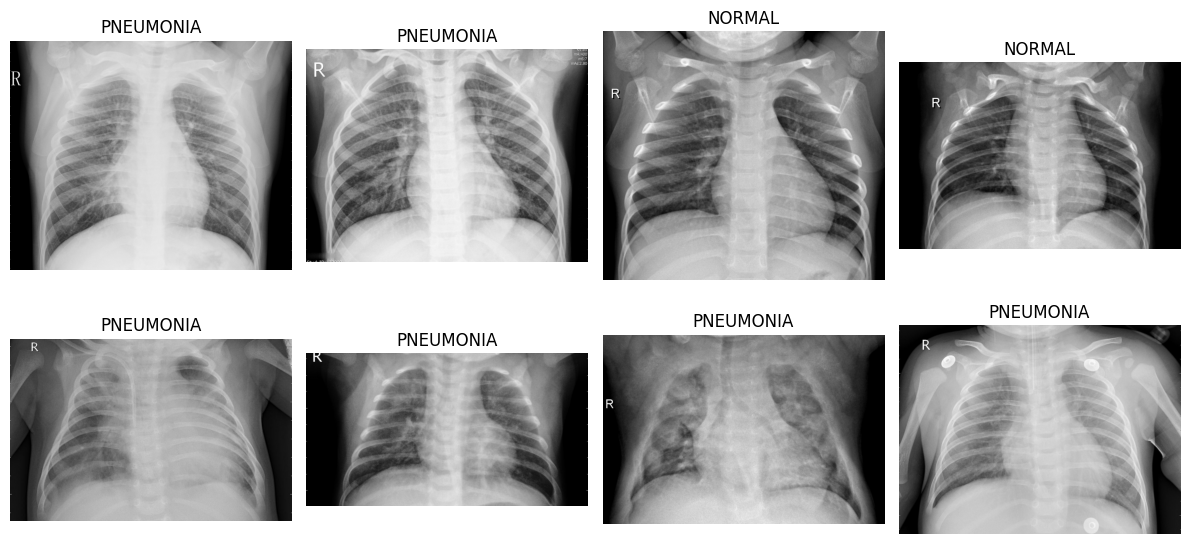

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    sample = dataset["train"][i]

    ax.imshow(sample["image"], cmap="gray")
    ax.set_title(dataset["train"].features["label"].names[sample["label"]])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
!git clone https://github.com/HugoGarciaArocas1/Research-Innovation-management.git

Cloning into 'Research-Innovation-management'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 15 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 507.61 KiB | 4.66 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [8]:
!pip install -q codecarbon datasets torchmetrics thop pynvml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 402.7/402.7 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 73.4 MB/s eta 0:00:00


In [9]:
import os
import time
import json
import math
import random
import threading
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from datasets import load_dataset

from codecarbon import EmissionsTracker

import psutil

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2), "GB")
else:
    print("⚠️ No se ha detectado GPU.")

PyTorch: 2.11.0+cpu
Device: cpu
⚠️ No se ha detectado GPU.


In [10]:
dataset = load_dataset(
    "hf-vision/chest-xray-pneumonia"
)

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 5216
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 16
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 624
    })
})


In [11]:
for split in dataset:
    print(f"\n{split}")
    print(dataset[split])
    print("Features:", dataset[split].features)


train
Dataset({
    features: ['image', 'label'],
    num_rows: 5216
})
Features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['NORMAL', 'PNEUMONIA'])}

validation
Dataset({
    features: ['image', 'label'],
    num_rows: 16
})
Features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['NORMAL', 'PNEUMONIA'])}

test
Dataset({
    features: ['image', 'label'],
    num_rows: 624
})
Features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['NORMAL', 'PNEUMONIA'])}


dict_keys(['image', 'label'])
Label: 0
Image: <PIL.JpegImagePlugin.JpegImageFile image mode=L size=2090x1858 at 0x78B2B93B1350>


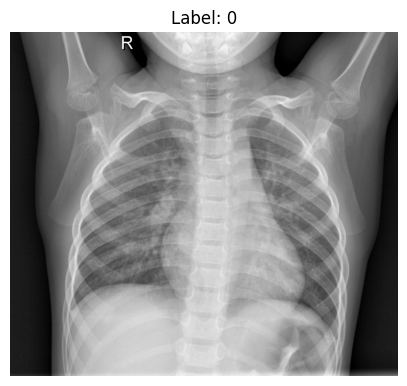

In [12]:
sample = dataset["train"][0]

print(sample.keys())

image = sample["image"]
label = sample["label"]

print("Label:", label)
print("Image:", image)

plt.figure(figsize=(5, 5))
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.title(f"Label: {label}")
plt.show()

In [13]:
# Mostrar información de las etiquetas
for split in dataset:
    labels = dataset[split]["label"]
    unique, counts = np.unique(labels, return_counts=True)

    print(f"\n{split}:")
    for label, count in zip(unique, counts):
        print(f"  Clase {label}: {count} imágenes")


train:
  Clase 0: 1341 imágenes
  Clase 1: 3875 imágenes

validation:
  Clase 0: 8 imágenes
  Clase 1: 8 imágenes

test:
  Clase 0: 234 imágenes
  Clase 1: 390 imágenes


In [14]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [15]:
class ChestXRayDataset(torch.utils.data.Dataset):

    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        item = self.dataset[idx]

        image = item["image"]
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [16]:
train_dataset = ChestXRayDataset(
    dataset["train"],
    transform=train_transform
)

test_split_name = "test" if "test" in dataset else "validation"

test_dataset = ChestXRayDataset(
    dataset[test_split_name],
    transform=test_transform
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Training samples: 5216
Test samples: 624


In [17]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 163
Test batches: 20


In [18]:
class LightCNN(nn.Module):

    def __init__(self, num_classes=2):

        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

In [19]:
def create_resnet18():

    model = resnet18(weights=None)

    model.fc = nn.Linear(
        model.fc.in_features,
        2
    )

    return model

In [20]:
def count_parameters(model):

    total = sum(
        p.numel()
        for p in model.parameters()
    )

    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    return total, trainable

In [21]:
cnn = LightCNN().to(device)
resnet = create_resnet18().to(device)

cnn_total, cnn_trainable = count_parameters(cnn)
resnet_total, resnet_trainable = count_parameters(resnet)

print("LightCNN")
print("Total parameters:", f"{cnn_total:,}")
print("Trainable parameters:", f"{cnn_trainable:,}")

print("\nResNet-18")
print("Total parameters:", f"{resnet_total:,}")
print("Trainable parameters:", f"{resnet_trainable:,}")

LightCNN
Total parameters: 93,954
Trainable parameters: 93,954

ResNet-18
Total parameters: 11,177,538
Trainable parameters: 11,177,538


In [22]:
from thop import profile

dummy_input = torch.randn(
    1, 3, IMG_SIZE, IMG_SIZE
).to(device)

cnn_flops, _ = profile(
    LightCNN().to(device),
    inputs=(dummy_input,),
    verbose=False
)

resnet_flops, _ = profile(
    create_resnet18().to(device),
    inputs=(dummy_input,),
    verbose=False
)

print("LightCNN FLOPs:", f"{cnn_flops:,.0f}")
print("ResNet-18 FLOPs:", f"{resnet_flops:,.0f}")

LightCNN FLOPs: 517,114,240
ResNet-18 FLOPs: 1,823,522,816


In [23]:
monitoring_data = []

monitoring = False


def monitor_resources(interval=1):

    global monitoring

    while monitoring:

        cpu_percent = psutil.cpu_percent(interval=None)
        ram_percent = psutil.virtual_memory().percent

        gpu_percent = np.nan
        gpu_memory_mb = np.nan

        if torch.cuda.is_available():

            try:
                import pynvml

                pynvml.nvmlInit()

                handle = pynvml.nvmlDeviceGetHandleByIndex(0)

                utilization = pynvml.nvmlDeviceGetUtilizationRates(handle)
                memory = pynvml.nvmlDeviceGetMemoryInfo(handle)

                gpu_percent = utilization.gpu
                gpu_memory_mb = memory.used / (1024 ** 2)

            except Exception:
                pass

        monitoring_data.append({
            "timestamp": time.time(),
            "cpu_percent": cpu_percent,
            "ram_percent": ram_percent,
            "gpu_percent": gpu_percent,
            "gpu_memory_mb": gpu_memory_mb
        })

        time.sleep(interval)

In [24]:
def train_model(
    model,
    model_name,
    epochs=5,
    learning_rate=0.001
):

    global monitoring
    global monitoring_data

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    history = []

    # Limpiar monitorización anterior
    monitoring_data = []

    # CodeCarbon
    tracker = EmissionsTracker(
        project_name=model_name,
        measure_power_secs=1,
        log_level="error"
    )

    print("\n" + "=" * 60)
    print(f"ENTRENANDO: {model_name}")
    print("=" * 60)

    # Empezar monitorización
    monitoring = True

    monitor_thread = threading.Thread(
        target=monitor_resources,
        daemon=True
    )

    monitor_thread.start()

    # Empezar CodeCarbon
    tracker.start()

    start_time = time.time()

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        epoch_start = time.time()

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

        epoch_loss = running_loss / total
        epoch_accuracy = correct / total

        epoch_time = time.time() - epoch_start

        history.append({
            "epoch": epoch + 1,
            "loss": epoch_loss,
            "accuracy": epoch_accuracy,
            "time": epoch_time
        })

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Loss: {epoch_loss:.4f} | "
            f"Accuracy: {epoch_accuracy:.4f} | "
            f"Time: {epoch_time:.2f}s"
        )

    total_time = time.time() - start_time

    # Parar CodeCarbon
    emissions = tracker.stop()

    # Parar monitor
    monitoring = False
    monitor_thread.join(timeout=2)

    # Convertir monitorización a DataFrame
    monitoring_df = pd.DataFrame(
        monitoring_data
    )

    return (
        model,
        history,
        total_time,
        emissions,
        monitoring_df
    )

In [25]:
def evaluate_model(model):

    model.eval()

    correct = 0
    total = 0

    running_loss = 0.0

    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    accuracy = correct / total
    loss = running_loss / total

    return loss, accuracy

In [ ]:
EPOCHS = 5

cnn_model = LightCNN()

cnn_model, cnn_history, cnn_time, cnn_emissions, cnn_monitor = train_model(
    cnn_model,
    model_name="LightCNN",
    epochs=EPOCHS,
    learning_rate=0.001
)

[codecarbon WARNING @ 13:20:18] Multiple instances of codecarbon are allowed to run at the same time.



ENTRENANDO: LightCNN


In [ ]:
cnn_test_loss, cnn_test_accuracy = evaluate_model(
    cnn_model
)

print("\nLightCNN test results")
print("---------------------")
print("Test loss:", cnn_test_loss)
print("Test accuracy:", cnn_test_accuracy)
print("Training time:", cnn_time, "seconds")
print("Energy/emissions value:", cnn_emissions)

In [ ]:
resnet_model = create_resnet18()

resnet_model, resnet_history, resnet_time, resnet_emissions, resnet_monitor = train_model(
    resnet_model,
    model_name="ResNet18",
    epochs=EPOCHS,
    learning_rate=0.001
)

In [ ]:
resnet_test_loss, resnet_test_accuracy = evaluate_model(
    resnet_model
)

print("\nResNet-18 test results")
print("---------------------")
print("Test loss:", resnet_test_loss)
print("Test accuracy:", resnet_test_accuracy)
print("Training time:", resnet_time, "seconds")
print("Energy/emissions value:", resnet_emissions)

In [ ]:
import glob

files = glob.glob("*.csv")

print("CSV files generated:")
for f in files:
    print(f)

In [ ]:
for file in files:

    print("\n" + "=" * 60)
    print(file)
    print("=" * 60)

    try:
        df = pd.read_csv(file)
        display(df.tail())
    except:
        pass

In [ ]:
def resource_summary(df):

    summary = {}

    if len(df) == 0:
        return summary

    summary["CPU mean (%)"] = df["cpu_percent"].mean()

    summary["CPU max (%)"] = df["cpu_percent"].max()

    summary["RAM mean (%)"] = df["ram_percent"].mean()

    summary["RAM max (%)"] = df["ram_percent"].max()

    if df["gpu_percent"].notna().any():

        summary["GPU mean (%)"] = df["gpu_percent"].mean()
        summary["GPU max (%)"] = df["gpu_percent"].max()

    if df["gpu_memory_mb"].notna().any():

        summary["GPU memory mean (MB)"] = (
            df["gpu_memory_mb"].mean()
        )

        summary["GPU memory max (MB)"] = (
            df["gpu_memory_mb"].max()
        )

    return summary

In [ ]:
results = pd.DataFrame({

    "Metric": [
        "Parameters",
        "FLOPs",
        "Training time (s)",
        "Test accuracy",
        "Test loss",
        "CPU mean (%)",
        "RAM mean (%)",
        "GPU mean (%)",
        "GPU memory max (MB)"
    ],

    "LightCNN": [
        cnn_total,
        cnn_flops,
        cnn_time,
        cnn_test_accuracy,
        cnn_test_loss,
        cnn_resources.get("CPU mean (%)", np.nan),
        cnn_resources.get("RAM mean (%)", np.nan),
        cnn_resources.get("GPU mean (%)", np.nan),
        cnn_resources.get("GPU memory max (MB)", np.nan)
    ],

    "ResNet-18": [
        resnet_total,
        resnet_flops,
        resnet_time,
        resnet_test_accuracy,
        resnet_test_loss,
        resnet_resources.get("CPU mean (%)", np.nan),
        resnet_resources.get("RAM mean (%)", np.nan),
        resnet_resources.get("GPU mean (%)", np.nan),
        resnet_resources.get("GPU memory max (MB)", np.nan)
    ]
})

display(results)

In [ ]:
cnn_acc = [x["accuracy"] for x in cnn_history]
resnet_acc = [x["accuracy"] for x in resnet_history]

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    cnn_acc,
    marker="o",
    label="LightCNN"
)

plt.plot(
    epochs_range,
    resnet_acc,
    marker="o",
    label="ResNet-18"
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
cnn_loss = [x["loss"] for x in cnn_history]
resnet_loss = [x["loss"] for x in resnet_history]

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    cnn_loss,
    marker="o",
    label="LightCNN"
)

plt.plot(
    epochs_range,
    resnet_loss,
    marker="o",
    label="ResNet-18"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
models = ["LightCNN", "ResNet-18"]
times = [cnn_time, resnet_time]

plt.figure(figsize=(7, 5))

plt.bar(models, times)

plt.ylabel("Time (seconds)")
plt.title("Training Time Comparison")

plt.show()

In [ ]:
parameters = [
    cnn_total,
    resnet_total
]

plt.figure(figsize=(7, 5))

plt.bar(
    models,
    parameters
)

plt.ylabel("Number of parameters")
plt.title("Model Complexity")

plt.show()

In [ ]:
results.to_csv(
    "model_comparison_results.csv",
    index=False
)

cnn_monitor.to_csv(
    "lightcnn_resource_monitor.csv",
    index=False
)

resnet_monitor.to_csv(
    "resnet18_resource_monitor.csv",
    index=False
)

print("Results saved.")

In [ ]:
torch.save(
    cnn_model.state_dict(),
    "lightcnn.pth"
)

torch.save(
    resnet_model.state_dict(),
    "resnet18.pth"
)

print("Models saved.")

In [ ]:
final_comparison = pd.DataFrame({

    "Metric": [
        "Architecture",
        "Parameters",
        "FLOPs",
        "Training time (s)",
        "Test accuracy (%)",
        "Test loss",
        "Mean CPU (%)",
        "Mean RAM (%)",
        "Mean GPU (%)",
        "Max GPU memory (MB)"
    ],

    "LightCNN": [
        "3-block CNN",
        f"{cnn_total:,}",
        f"{cnn_flops:,.0f}",
        f"{cnn_time:.2f}",
        f"{cnn_test_accuracy * 100:.2f}",
        f"{cnn_test_loss:.4f}",
        f"{cnn_resources.get('CPU mean (%)', np.nan):.2f}",
        f"{cnn_resources.get('RAM mean (%)', np.nan):.2f}",
        f"{cnn_resources.get('GPU mean (%)', np.nan):.2f}",
        f"{cnn_resources.get('GPU memory max (MB)', np.nan):.2f}"
    ],

    "ResNet-18": [
        "ResNet-18",
        f"{resnet_total:,}",
        f"{resnet_flops:,.0f}",
        f"{resnet_time:.2f}",
        f"{resnet_test_accuracy * 100:.2f}",
        f"{resnet_test_loss:.4f}",
        f"{resnet_resources.get('CPU mean (%)', np.nan):.2f}",
        f"{resnet_resources.get('RAM mean (%)', np.nan):.2f}",
        f"{resnet_resources.get('GPU mean (%)', np.nan):.2f}",
        f"{resnet_resources.get('GPU memory max (MB)', np.nan):.2f}"
    ]
})

display(final_comparison)